# Finding optimal parameters for the Random Forest model
In order to find the parameters that will make the model best predict the classes of proteins, hyperparameter tuning needs to be done. I am demonstrating in this Jupyter notebook how I have found the parameters that give me the most accurate result on an evaluation set. 

First, I am importing the packages and libraries that I will need:

In [12]:
import sys
sys.path.append("..") #I need this to import the dictionaries and functions modules, since they are in the parent directory of the current file
from dictionaries import amino_acids, motifs 
from functions import dataset_preparation_for_rf

import pandas as pd
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

Then, I read in my dataset that I prepared using the [create_datasets.py](./classify/supplementary_materials/datasets/create_datasets.py) script and a UniProt dataset (SwissProt entries). The head of the dataset is shown.

In [3]:
df = pd.read_csv("/Users/bani4ki/Documents/programming_project_bioinformatics/classify/supplementary_materials/datasets/dataset_A.csv")

In [ ]:
df.head()

The dataset is then cleaned up, leaving the columns 'Entry', 'Sequence', and 'Functional_class', and some properties of the sequences are derived. Then they are then put into their own columns. All properties that will be used to train the model need to be numerical. I clean up the dataset and calculate sequence properties by using the function dataset_preparation_for_rf I created in [functions.py](./classify/functions.py).

In [4]:
df_rf = dataset_preparation_for_rf(df, amino_acids, motifs)

This is how the dataset looks now:

In [ ]:
df_rf.head()

In machine learning, "X" is the conventional variable name for the data be used to predict the class - "y". Here, the variable X contains all the sequence properties, and y contains the functional class. The UniProt entries of the proteins are put in a separate variable, as they are not used to train the model and do not contain information about the sequence, thus will be added to the results dataset later.

In [7]:
X,y = df_rf.loc[ : , (df_rf.columns != "Functional_class") & (df_rf.columns != "Entry") ], df_rf["Functional_class"]
entries = df_rf["Entry"]

The dataset is then split into three parts using the train_test_split function of the scikit-learn module: A train set, which is then split into a train set and an evaluation set used to tune the hyperparameters of the model, and a test set that will be used once and only once to evaluate the performance of the trained model. 

In [10]:
X_train, X_test, y_train, y_test, entry_train, entry_test = train_test_split(X,y,entries,test_size = 0.2, random_state = 42)

X_train, X_val, y_train, y_val = train_test_split(X_train,y_train,test_size = 0.25, random_state = 42)

As mentioned earlier, the Random Forest classifier handles only numerical data. Thus I am converting the class names to numerical codes using the LabelEncoder function of the scikit-learn library. I do this after splitting the data to avoind data leakage.

In [13]:
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
y_val = label_encoder.transform(y_val)
y_test = label_encoder.transform(y_test)

I am also scaling the data using the StandardScaler function of the scikit-learn library:

In [14]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) 
X_val = scaler.transform(X_val) 
X_test = scaler.transform(X_test)

I then fit an RF model to the training data. I use default parameters, and only provide a random seed number for reproducibility. To evaluate the performance of the model with standard settings, I fit it to the validation dataset. Using the accuracy score, classification report, and confusion matrix, I evaluate the performance of the model. With this particular dataset, an accuracy of about 90.9% is achieved. 

In [15]:
rf_model = RandomForestClassifier(random_state = 42)

rf_model.fit(X_train,y_train)

y_pred = rf_model.predict(X_val)

print(accuracy_score(y_val, y_pred))
print(classification_report(y_val,y_pred))
print(confusion_matrix(y_val,y_pred))

0.9092369477911647
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       111
           1       0.92      0.85      0.88       375
           2       0.97      0.55      0.70        53
           3       0.89      0.96      0.93       706

    accuracy                           0.91      1245
   macro avg       0.94      0.83      0.87      1245
weighted avg       0.91      0.91      0.91      1245

[[107   0   0   4]
 [  2 317   0  56]
 [  0   2  29  22]
 [  0  26   1 679]]


To tune the hyperparameters, I create the so-called parameter grid, where I plug in several of the parameters of the machine learning model with several values for each. Then, I use the GridSearchCV function to find the setting of the RF model that will produce the best performance results. EXPLAIN WHAT EACH MEANS!   
The function then evaluates the performance of the model on each unique combination of the provided settings in the parameter grid, and returns the best accuracy score and the most high-performing combination of parameters. In this case that would be 91.1% accuracy score and settings for the RandomForestClassifier bootstrap=False, max_depth=20, max_features='log2', n_estimators=200, random_state=42. 

In [ ]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 3,5, 10, 20],
    'max_features':["sqrt","log2", None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

grid_search = GridSearchCV(rf_model, param_grid, cv=10, scoring = 'accuracy', n_jobs = -1, verbose = 2)
grid_search.fit(X_train, y_train)
best_rf = grid_search.best_estimator_
print("Best Score:", grid_search.best_score_)
print("Best Estimator:", grid_search.best_estimator_)

In [28]:
print("Best Score:", grid_search.best_score_)
print("Best Estimator:", grid_search.best_estimator_)

Best Score: 0.9113073647689639
Best Estimator: RandomForestClassifier(bootstrap=False, max_depth=20, max_features='log2',
                       n_estimators=200, random_state=42)


I then fit the new, improved model to the train data, and test it on the test data. The accuracy score of the prediction is 91.5%, and the model performs the worst on class 3. 

In [27]:
best_rf.fit(X_train,y_train)
y_pred = best_rf.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

RandomForestClassifier(bootstrap=False, max_depth=20, max_features='log2',
                       n_estimators=200, random_state=42)
0.914859437751004
              precision    recall  f1-score   support

           0       0.99      0.91      0.95        94
           1       0.91      0.84      0.87       390
           2       1.00      0.79      0.88        33
           3       0.90      0.96      0.93       728

    accuracy                           0.91      1245
   macro avg       0.95      0.88      0.91      1245
weighted avg       0.92      0.91      0.91      1245

[[ 86   2   0   6]
 [  1 327   0  62]
 [  0   1  26   6]
 [  0  28   0 700]]


This is how the resulting dataset containing the predicted and actual classes of the test dataset looks:

In [29]:
results_df = pd.DataFrame({"Entry": entry_test,"Predicted_class": label_encoder.inverse_transform(y_pred),"Actual_class": label_encoder.inverse_transform(y_test)})
print(results_df.head())

       Entry             Predicted_class                Actual_class
469   Q5IS56               Transcription               Transcription
3670  Q9SND6                      Kinase                      Kinase
5470  O14626  G protein-coupled receptor  G protein-coupled receptor
4368  Q3T8J9               Transcription               Transcription
4427  Q9UNW8  G protein-coupled receptor  G protein-coupled receptor


To find out which properties of the sequences contribute the most to the model's decision, I make a plot with the several most important features. They can be obtained by the fitted model after the hyperparameter tuning. I find out the counts of two of the motifs found in the sequences are the most influential to the decision, and then the frequencies of hydrophobic and charged amino acids. When it comes to amino acid content, Isoleucine and Valine seem to play a big role in the functional class determination.

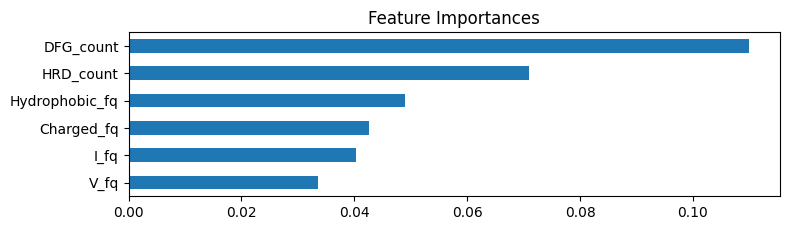

In [17]:
feature_importance = best_rf.feature_importances_
feature_names = X.columns
importances = pd.Series(best_rf.feature_importances_, index = X.columns).sort_values(ascending=True)
importances_filtered = importances[importances > 0.03]
fig, ax = plt.subplots(figsize=(8, len(importances_filtered) * 0.4))
importances_filtered.plot.barh(ax=ax)
ax.set_title('Feature Importances')
plt.tight_layout()
plt.show()